# ESERCIZIO DEEP LEARNING

Applicare un modello di deep leaning con keras ai dataset titanic e house pricing

Attenzione a gestire correttamente l'ultimo layer

Provare poi anche numeri di layer e di neuroni diversi

Attenzione le reti neurali non gestiscono da sole i valori nulli come fa xgboost

## workflow

pulizia → feature engineering → split → scaling corretto (no leakage) → training con anti-overfitting → valutazione + grafici → soglia migliore.

## 1) Caricamento dataset e ispezione iniziale

Carichiamo il dataset di training (contiene la variabile target `Transported`) e controlliamo:
- prime righe
- tipi di dato
- valori nulli

In [93]:
import pandas as pd
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.regularizers import l2
from keras.layers import BatchNormalization
from keras.layers import Dense, Flatten, Dropout

df_raw = pd.read_csv("train.csv")

print(df_raw.head())
print(df_raw.info())
print(df_raw.isnull().sum())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  
<c

## 2) Copia di lavoro

Creiamo una copia del dataframe per lavorare senza perdere l'originale.

In [94]:
df = df_raw.copy()

## 3) Preparazione della target

`Transported` è booleana (True/False). La convertiamo in 0/1.

In [95]:
df["Transported"] = df["Transported"].astype(int)

## 4) Feature engineering sulla colonna Cabin

La colonna `Cabin` contiene informazioni nella forma:
Deck/Number/Side (es: "B/45/P")

La separiamo in 3 colonne:
- Deck (categoria)
- CabinNum (numero)
- Side (categoria)

In [96]:
# split cabin in 3 parti
df[["Deck", "CabinNum", "Side"]] = df["Cabin"].str.split("/", expand=True)

# converte CabinNum in numerico (NaN se mancante)
df["CabinNum"] = pd.to_numeric(df["CabinNum"])

# rimuove Cabin originale
df = df.drop(columns=["Cabin"])

## 5) Feature engineering sulle spese

Le spese sono molto informative.
Creiamo:
- `SpesaTotale` = somma di tutte le spese
- `NessunaSpesa` = 1 se la spesa totale è 0, altrimenti 0

In [97]:
cols_spese = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# prima riempiamo NaN delle spese con 0 (per sommare correttamente)
for col in cols_spese:
    df[col] = df[col].fillna(0)

df["SpesaTotale"] = df[cols_spese].sum(axis=1)
df["NessunaSpesa"] = (df["SpesaTotale"] == 0).astype(int)

## 6) Gestione valori nulli

Le reti neurali non gestiscono NaN, quindi li eliminiamo con imputazione semplice:

- categorie: moda (valore più frequente) o "Unknown"
- booleani: False
- numerici: mediana

In [98]:
# categorie
df["HomePlanet"] = df["HomePlanet"].fillna(df["HomePlanet"].mode()[0])
df["Destination"] = df["Destination"].fillna(df["Destination"].mode()[0])

df["Deck"] = df["Deck"].fillna("Unknown")
df["Side"] = df["Side"].fillna("Unknown")

# booleani (nel dataset spesso sono object, li gestiamo dopo)
df["CryoSleep"] = df["CryoSleep"].fillna(False)
df["VIP"] = df["VIP"].fillna(False)

# numerici
df["Age"] = df["Age"].fillna(df["Age"].median())
df["CabinNum"] = df["CabinNum"].fillna(df["CabinNum"].median())

# Name non utile (in prima versione)
df = df.drop(columns=["Name"])

# PassengerId non utile al modello
df = df.drop(columns=["PassengerId"])

/tmp/ipykernel_306/3978478610.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["CryoSleep"] = df["CryoSleep"].fillna(False)
/tmp/ipykernel_306/3978478610.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["VIP"] = df["VIP"].fillna(False)


## 7) Conversione variabili categoriche in numeriche

- Convertiamo `CryoSleep` e `VIP` in 0/1
- Applichiamo one-hot encoding alle categorie (`HomePlanet`, `Destination`, `Deck`, `Side`)

In [99]:
# booleani -> int
df["CryoSleep"] = df["CryoSleep"].astype(int)
df["VIP"] = df["VIP"].astype(int)

# one-hot encoding categorie
df = pd.get_dummies(df, columns=["HomePlanet", "Destination", "Deck", "Side"], drop_first=False)

print(df.shape)
print(df.head())

(8693, 30)
   CryoSleep   Age  VIP  RoomService  FoodCourt  ShoppingMall     Spa  VRDeck  \
0          0  39.0    0          0.0        0.0           0.0     0.0     0.0   
1          0  24.0    0        109.0        9.0          25.0   549.0    44.0   
2          0  58.0    1         43.0     3576.0           0.0  6715.0    49.0   
3          0  33.0    0          0.0     1283.0         371.0  3329.0   193.0   
4          0  16.0    0        303.0       70.0         151.0   565.0     2.0   

   Transported  CabinNum  ...  Deck_C  Deck_D  Deck_E  Deck_F  Deck_G  Deck_T  \
0            0       0.0  ...   False   False   False   False   False   False   
1            1       0.0  ...   False   False   False    True   False   False   
2            0       0.0  ...   False   False   False   False   False   False   
3            0       0.0  ...   False   False   False   False   False   False   
4            1       1.0  ...   False   False   False    True   False   False   

   Deck_Unknown

## 8) Train/Test split (con stratify)

Dividiamo:
- X = feature
- y = target

Usiamo `stratify=y` per mantenere proporzioni simili delle classi nei due set.

In [100]:
from sklearn.model_selection import train_test_split

X = df.drop("Transported", axis=1)
y = df["Transported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Distribuzione y (train):")
print(y_train.value_counts(normalize=True))

X_train: (6954, 29) X_test: (1739, 29)
Distribuzione y (train):
Transported
1    0.503595
0    0.496405
Name: proportion, dtype: float64


## 9) Standardizzazione corretta (NO data leakage)

Lo scaler va fittato **solo su X_train** e applicato a X_test.
Useremo StandardScaler (media 0, dev standard 1).

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(X_train_scaled.shape, X_test_scaled.shape)

(6954, 29) (1739, 29)


## 10) Modello Keras migliorato (anti-overfitting)

Usiamo un modello più adatto ai dataset tabellari:
- Dense (256 -> 128 -> 64)
- BatchNormalization (training più stabile)
- Dropout (riduce overfitting)
- L2 leggero (regolarizza i pesi)
- Output sigmoid (classificazione binaria)

In [102]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Dense(256, activation="relu", input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(1e-5)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(128, activation="relu", kernel_regularizer=l2(1e-5)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu", kernel_regularizer=l2(1e-5)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 256)            │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,689 (198.00 KB)

 Trainable params: 49,793 (194.50 KB)

 Non-trainable params: 896 (3.50 KB)

## 11) Callback per generalizzazione

- EarlyStopping: ferma il training se la validation non migliora
- Restore best weights: mantiene il modello migliore
- ReduceLROnPlateau: riduce learning rate se la val_loss è ferma

In [103]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

## 12) Addestramento

Alleniamo il modello usando:
- validation_split sul training set (20%)
- callbacks per evitare overfitting e migliorare convergenza

In [104]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6719 - loss: 0.6819 - val_accuracy: 0.7743 - val_loss: 0.5015 - learning_rate: 0.0010
Epoch 2/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7492 - loss: 0.5130 - val_accuracy: 0.7944 - val_loss: 0.4620 - learning_rate: 0.0010
Epoch 3/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7789 - loss: 0.4571 - val_accuracy: 0.7965 - val_loss: 0.4311 - learning_rate: 0.0010
Epoch 4/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7775 - loss: 0.4495 - val_accuracy: 0.7951 - val_loss: 0.4219 - learning_rate: 0.0010
Epoch 5/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7856 - loss: 0.4350 - val_accuracy: 0.7965 - val_loss: 0.4269 - learning_rate: 0.0010
Epoch 6/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7924 - loss: 0.4294 - val_accuracy: 0.8009 - val_loss: 0.4267 - learning_rate: 0.0010
Epoch 7/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7832 - loss: 0.4448 - val_ac

## 13) Valutazione sul test set

Valutiamo accuracy e loss sul test set (dati non visti durante training).

In [105]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.3908642828464508
Test accuracy: 0.8056354522705078


## 14) Grafici di training: loss e accuracy

Visualizziamo l'andamento di:
- loss (train e validation)
- accuracy (train e validation)

Se la training accuracy continua a salire mentre la validation peggiora,
è un segnale di overfitting.

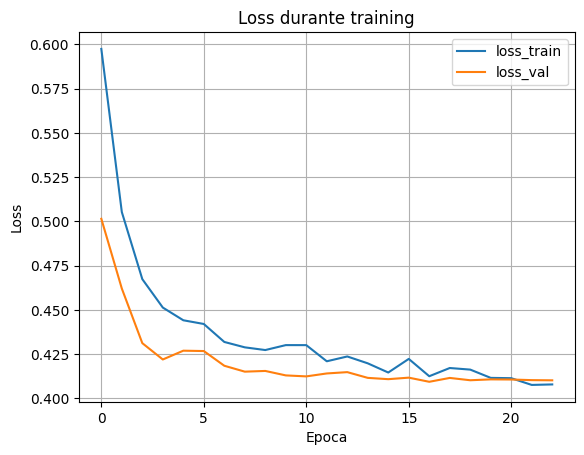

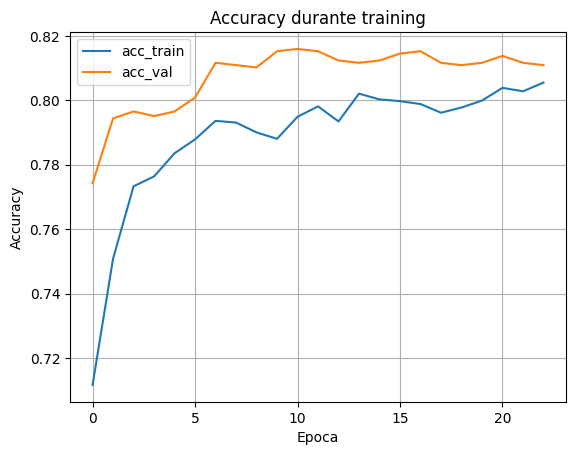

In [106]:
import matplotlib.pyplot as plt

# LOSS
plt.figure()
plt.plot(history.history["loss"], label="loss_train")
plt.plot(history.history["val_loss"], label="loss_val")
plt.title("Loss durante training")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ACCURACY
plt.figure()
plt.plot(history.history["accuracy"], label="acc_train")
plt.plot(history.history["val_accuracy"], label="acc_val")
plt.title("Accuracy durante training")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 15) Scelta della soglia migliore

Con output sigmoid otteniamo probabilità.
La soglia standard è 0.5, ma possiamo cercare una soglia che massimizza accuracy sul test set.

In [107]:
import numpy as np

y_prob = model.predict(X_test_scaled).ravel()

soglie = np.linspace(0.2, 0.8, 31)
best_soglia = 0.5
best_acc = 0

for s in soglie:
    y_pred = (y_prob >= s).astype(int)
    acc = (y_pred == y_test.values).mean()
    if acc > best_acc:
        best_acc = acc
        best_soglia = s

print("Best soglia:", best_soglia)
print("Best accuracy con soglia:", best_acc)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Best soglia: 0.48000000000000004
Best accuracy con soglia: 0.8079355951696378


## 16) Confusion matrix e report (binaria)

Convertiamo le probabilità in classi usando la soglia migliore e calcoliamo:
- confusion matrix
- precision, recall, f1-score

In [108]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_classi = (y_prob >= best_soglia).astype(int)
y_true = y_test.values.astype(int)

print(classification_report(y_true, y_pred_classi))

cm = confusion_matrix(y_true, y_pred_classi)
print("Confusion matrix:\n", cm)

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       863
           1       0.81      0.81      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739

Confusion matrix:
 [[698 165]
 [169 707]]


## 17) Optuna (opzionale)

Optuna prova automaticamente combinazioni di iperparametri:
- numero layer
- neuroni
- dropout
- L2
- learning rate

In [110]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.7 MB/s eta 0:00:00


In [111]:
import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

## 18) Funzione obiettivo Optuna

Ogni trial:
- costruisce un modello con iperparametri diversi
- allena con EarlyStopping
- restituisce la migliore val_accuracy

In [112]:
def objective(trial):
    n_layers = trial.suggest_int("n_layers", 2, 4)
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    l2_reg = trial.suggest_float("l2", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    model = Sequential()
    neuroni_primo = trial.suggest_categorical("neuroni_0", [64, 128, 256])

    model.add(Dense(neuroni_primo, activation="relu", input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))

    for i in range(1, n_layers):
        neuroni = trial.suggest_categorical(f"neuroni_{i}", [32, 64, 128, 256])
        model.add(Dense(neuroni, activation="relu", kernel_regularizer=l2(l2_reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
    ]

    history = model.fit(
        X_train_scaled, y_train,
        epochs=150,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=0
    )

    best_val_acc = max(history.history["val_accuracy"])
    return best_val_acc

## 19) Esecuzione Optuna

Eseguiamo un numero contenuto di trial (es: 20) per rimanere in ambito didattico.

In [113]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best value (val_accuracy):", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-05 13:57:51,370] A new study created in memory with name: no-name-6061a7e4-80ef-43f3-be9c-c9f5aabe008d
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-03-05 13:58:27,084] Trial 0 finished with value: 0.8073328733444214 and parameters: {'n_layers': 3, 'lr': 0.00023394123040186983, 'dropout': 0.17791936007298165, 'l2': 0.00014391064383440676, 'batch_size': 32, 'neuroni_0': 64, 'neuroni_1': 64, 'neuroni_2': 32}. Best is trial 0 with value: 0.8073328733444214.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer 

Best value (val_accuracy): 0.8281811475753784
Best params: {'n_layers': 4, 'lr': 0.001645796725026597, 'dropout': 0.26582175254343887, 'l2': 0.0003866396300110112, 'batch_size': 128, 'neuroni_0': 64, 'neuroni_1': 32, 'neuroni_2': 256, 'neuroni_3': 128}


## 20) Addestramento finale con i migliori parametri trovati

Ricostruiamo il modello con i best params e valutiamo sul test set.

In [114]:
best = study.best_params

model = Sequential()

model.add(Dense(best["neuroni_0"], activation="relu", input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(best["l2"])))
model.add(BatchNormalization())
model.add(Dropout(best["dropout"]))

for i in range(1, best["n_layers"]):
    model.add(Dense(best[f"neuroni_{i}"], activation="relu", kernel_regularizer=l2(best["l2"])))
    model.add(BatchNormalization())
    model.add(Dropout(best["dropout"]))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer=Adam(learning_rate=best["lr"]),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=best["batch_size"],
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6193 - loss: 0.8683 - val_accuracy: 0.6729 - val_loss: 0.7233 - learning_rate: 0.0016
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7048 - loss: 0.6973 - val_accuracy: 0.7721 - val_loss: 0.6549 - learning_rate: 0.0016
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7240 - loss: 0.6397 - val_accuracy: 0.7886 - val_loss: 0.6091 - learning_rate: 0.0016
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7573 - loss: 0.6178 - val_accuracy: 0.7879 - val_loss: 0.5806 - learning_rate: 0.0016
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7620 - loss: 0.5984 - val_accuracy: 0.7951 - val_loss: 0.5608 - learning_rate: 0.0016
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7634 - loss: 0.5901 - val_accuracy: 0.7951 - val_loss: 0.5371 - learning_rate: 0.0016
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7737 - loss: 0.5617 - val_accuracy: 0.80

## grafici

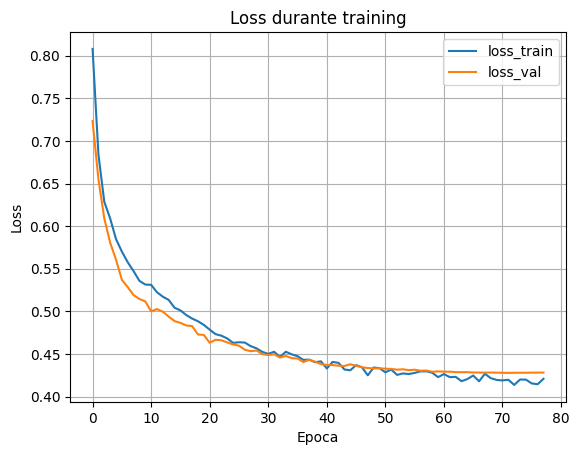

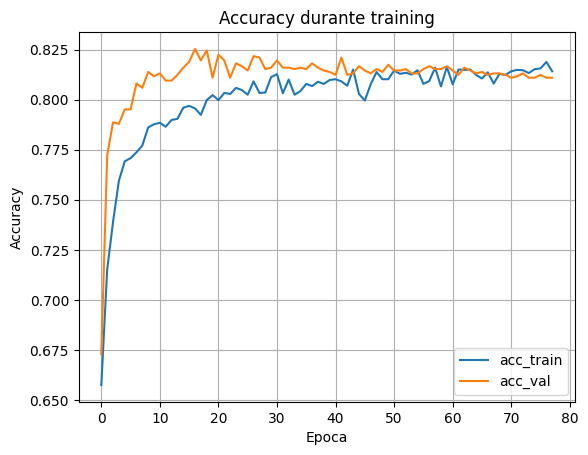

In [115]:
import matplotlib.pyplot as plt

# LOSS
plt.figure()
plt.plot(history.history["loss"], label="loss_train")
plt.plot(history.history["val_loss"], label="loss_val")
plt.title("Loss durante training")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ACCURACY
plt.figure()
plt.plot(history.history["accuracy"], label="acc_train")
plt.plot(history.history["val_accuracy"], label="acc_val")
plt.title("Accuracy durante training")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()